# Deep Learning Coursework
Zhengyang Li, Yaohuan Xie, Jacques Zhang

## Data Preparation and Processing

In [ ]:
import numpy as np
import numpy.random as npr
import tensorflow.keras as keras
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
plt.style.use('ggplot')


# set seed for randomness
np.random.seed(42)

In [ ]:
# read the Data A
data_a = pd.read_csv("DL-2024-CW-data/Data_A.csv", header=None)
data_labels = data_a[0].to_numpy()
data_labels_arr = data_labels.reshape(-1, 1)
data_arr_a = data_a.to_numpy()

# clip the data
data_clipped = data_a.copy()
data_clipped.iloc[:, 1:17] = data_clipped.iloc[:, 1:17].clip(upper=data_clipped.iloc[:, 1:17].quantile(0.9), axis=1)
data_arr_clipped = data_clipped.to_numpy()

In [ ]:
# the function for standardising the data
def standardise(X):
    """
    Return the standardised version of X.
    """
    # max_val = np.max(X, 0)
    # X = X / max_val

    mu = np.mean(X, 0)
    sigma = np.std(X, 0)
    X_std = (X - mu) / sigma
    return mu, sigma, X_std


# organise the training data as model input
def standardise_features(arr, infer=False):
    # if arr.shape[1] == 22:
    #     # price and volume
    #     features_1 = arr[:, 1:17]
    #     # previous states
    #     features_2 = arr[:, 17:]

    # if arr.shape[1] == 21:
    #     # price and volume
    #     features_1 = arr[:, 0:16]
    #     # previous states
    #     features_2 = arr[:, 16:]

    if infer is True:
        # price and volume
        features_1 = arr[:, :-5]
        # previous states
        features_2 = arr[:, -5:]
    else:
        # price and volume
        features_1 = arr[:, 1:-5]
        # previous states
        features_2 = arr[:, -5:]

    # standardise features 1
    mu, sigma, features_1_std = standardise(features_1)

    # concatenate the features
    features = np.hstack((features_1_std, features_2))

    return mu, sigma, features

/Users/lizhengyang/miniconda3/envs/ic_math/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
# generate the train and test data
data_shuff_1 = data_a.iloc[np.random.permutation(len(data_a))]

# we split train to test as 80:20
split_portion = 0.8
train_set_1, test_set_1 = np.split(data_shuff_1, [int(split_portion*(data_shuff_1.shape[0]))])

train_labels_1 = train_set_1[0].to_numpy()
train_labels_1 = train_labels_1.reshape(-1, 1)
train_X_1 = train_set_1.to_numpy()

test_labels_1 = test_set_1[0].to_numpy()
test_labels_1 = test_labels_1.reshape(-1, 1)
test_X_1 = test_set_1.to_numpy()


# indices for cross validation
folds_indexes = np.split(np.arange(len(train_labels_1)), 4)

# for clipping
# generate the train and test data
data_shuff_2 = data_clipped.iloc[np.random.permutation(len(data_clipped))]

# we split train to test as 80:20
split_portion = 0.8
train_set_2, test_set_2 = np.split(data_shuff_2, [int(split_portion*(data_shuff_2.shape[0]))])

train_labels_2 = train_set_2[0].to_numpy()
train_labels_2 = train_labels_2.reshape(-1, 1)
train_X_2 = train_set_2.to_numpy()

test_labels_2 = test_set_2[0].to_numpy()
test_labels_2 = test_labels_2.reshape(-1, 1)
test_X_2 = test_set_2.to_numpy()

In [ ]:
# for adding new features
def add_features(df, df_add=None):
    arr = df.to_numpy()

    # price and volume
    features_1 = arr[:, :-5]
    # previous states
    features_2 = arr[:, -5:]

    if df_add is not None:
        arr_add = df_add.to_numpy()
        features_1 = np.hstack((features_1, arr_add))

    # concatenate the features
    features = np.hstack((features_1, features_2))

    return features


# generate the train and test data
data_shuff_3 = data_a.iloc[np.random.permutation(len(data_a))]

data_add = pd.DataFrame()
# data_add['level 1 price ratio'] = np.log(data_shuff_3.loc[:, 1] / data_shuff_3.loc[:, 3])
# data_add['level 1 volume ratio'] = np.log(data_shuff_3.loc[:, 2] / data_shuff_3.loc[:, 4])
# data_add['level 2 price ratio'] = np.log(data_shuff_3.loc[:, 5] / data_shuff_3.loc[:, 7])
# data_add['level 2 volume ratio'] = np.log(data_shuff_3.loc[:, 6] / data_shuff_3.loc[:, 8])
data_add['price ratio'] = np.log((data_shuff_3.loc[:, 1] + data_shuff_3.loc[:, 5] + data_shuff_3.loc[:, 9] + data_shuff_3.loc[:, 13])
                                 / (data_shuff_3.loc[:, 3] + data_shuff_3.loc[:, 7] + data_shuff_3.loc[:, 11] + data_shuff_3.loc[:, 15]))
data_add['volume ratio'] = np.log((data_shuff_3.loc[:, 2] + data_shuff_3.loc[:, 6] + data_shuff_3.loc[:, 10] + data_shuff_3.loc[:, 14])
                                 / (data_shuff_3.loc[:, 4] + data_shuff_3.loc[:, 8] + data_shuff_3.loc[:, 12] + data_shuff_3.loc[:, 16]))

data_new_arr = add_features(data_shuff_3, df_add=data_add)

# we split train to test as 80:20
split_portion = 0.8
train_set_3, test_set_3 = np.split(data_new_arr, [int(split_portion*(data_new_arr.shape[0]))])

train_labels_3 = train_set_3[:, 0]
train_labels_3 = train_labels_3.reshape(-1, 1)
train_X_3 = train_set_3

test_labels_3 = test_set_3[:, 0]
test_labels_3 = test_labels_3.reshape(-1, 1)
test_X_3 = test_set_3

## Build Model

In [ ]:
# build the model
def build_model(dim_arr, activation="relu", dropout=False, dropout_rate=0.3):
    model = keras.Sequential()
    for i in range(1, len(dim_arr)):
        if i == 1:
            model.add(keras.layers.Dense(dim_arr[i], activation=activation, input_shape=(dim_arr[i-1],)))

        elif i == 2:
            model.add(keras.layers.Dense(dim_arr[i], activation=activation))
            if dropout:
                model.add(keras.layers.Dropout(dropout_rate))

        elif i == len(dim_arr)-1:
            model.add(keras.layers.Dense(dim_arr[i], activation="sigmoid"))

        else:
            model.add(keras.layers.Dense(dim_arr[i], activation=activation))
            if dropout:
                model.add(keras.layers.Dropout(dropout_rate))

    model.summary()

    return model

In [ ]:
# function for training the model
def train_model(X, y, val_X=None, val_y=None, standardise='same', dim_arr=[21, 64, 128, 64, 1], activation="relu",
                dropout=False, dropout_rate=0.3, learning_rate=0.01, optimizer='Adam', batch_size=500, epochs=20):
    mu, sigma, X_std = standardise_features(X)
    model = build_model(dim_arr, activation=activation, dropout=dropout, dropout_rate=dropout_rate)
    if optimizer == 'Adam':
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=["accuracy"])

    if optimizer == 'SGD':
        model.compile(optimizer=keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9, nesterov=True), loss="binary_crossentropy", metrics=["accuracy"])

    if (val_X is not None) and (val_y is not None):
        if standardise == 'naive':
            mu_val, sigma_val, val_X_std = standardise_features(val_X)
        if standardise == 'same':
            features_1 = val_X[:, 1:-5]
            features_2 = val_X[:, -5:]
            features_1 = (features_1 - mu) / sigma
            val_X_std = np.hstack((features_1, features_2))
        train_object = model.fit(X_std, y, batch_size=batch_size, epochs=epochs, validation_data=(val_X_std, val_y))
    if (val_X is None) and (val_y is None):
        train_object = model.fit(X_std, y, batch_size=batch_size, epochs=epochs)

    return train_object

## Cross-Validation

In [ ]:
# function for computing the average validation accuracy for cross validation
def cv_score(train_list):
    score_list = []
    for train_item in train_list:
        sorted_accuracy = sorted(train_item.history["val_accuracy"])
        score_val = np.mean(sorted_accuracy[-5:])
        score_list.append(score_val)
    return np.mean(score_list)


# function for claculate the performance metric of cross validation for a certain model architecture
def cross_validation_model_shape(X_train, y_train, folds, dim_arr, dropout=False, dropout_rate=0.3, learning_rate=0.01, optimizer='Adam', batch_size=500, epochs=20):
    """
    Claculate the performance metric of cross validation
    """
    train_list = []
    # convert data frames to ndarrays
    X_train_arr = X_train
    y_train_arr = y_train

    # implement the cross validation
    for i in range(len(folds)):
        # get the indexes in this fold
        val_indexes = folds[i]
        train_indexes = list(set(range(y_train_arr.shape[0])) - set(val_indexes))

        # get the training and testing data in this fold
        X_train_i = X_train_arr[train_indexes, :]
        y_train_i = y_train_arr[train_indexes]

        X_val_i = X_train_arr[val_indexes, :]
        y_val_i = y_train_arr[val_indexes]
        # X_val_i_pd = pd.DataFrame(X_val_i, columns=sample_labels)
        # y_val_i_pd = pd.Series(y_val_i)

        # perform training using the data from this fold
        train_tmp = train_model(X_train_i, y_train_i, val_X=X_val_i, val_y=y_val_i, dim_arr=dim_arr, dropout=dropout, 
                                                       dropout_rate=dropout_rate, learning_rate=learning_rate, optimizer=optimizer, batch_size=batch_size, epochs=epochs)
        train_list.append(train_tmp)

    # compute the score
    score_val = cv_score(train_list)

    # Return the score
    return score_val


# function for choosing the optimal shape of the model
def choose_optinal_model_shape(X_train, y_train, folds, shape_list, dropout=False, dropout_rate=0.3, learning_rate=0.01, optimizer='Adam', batch_size=500, epochs=20):
    """
    Choose the optimal model shape by cross-validation
    """
    # initialise the vector of scores for max_depth
    depth_scores = np.zeros((len(shape_list),))

    # iterate through the proposed parameters and compute the repected scores
    for i, d in enumerate(shape_list):
        depth_scores[i] = cross_validation_model_shape(X_train, y_train, folds, d, dropout=dropout, 
                                                       dropout_rate=dropout_rate, learning_rate=learning_rate, optimizer=optimizer, batch_size=batch_size, epochs=epochs)
        print(f'CV@shape={d}: {depth_scores[i]:.3f}')
        # record the optimal parameter
        best_d_index = np.argmax(depth_scores)
    return depth_scores, shape_list[best_d_index]


# function for claculate the performance metric of cross validation for a certain learning rate
def cross_validation_model_rate(X_train, y_train, folds, dim_arr, dropout=False, dropout_rate=0.3, learning_rate=0.01, optimizer='Adam', batch_size=500, epochs=20):
    """
    Claculate the performance metric of cross validation
    """
    train_list = []
    # convert data frames to ndarrays
    X_train_arr = X_train
    y_train_arr = y_train

    # implement the cross validation
    for i in range(len(folds)):
        # get the indexes in this fold
        val_indexes = folds[i]
        train_indexes = list(set(range(y_train_arr.shape[0])) - set(val_indexes))

        # get the training and testing data in this fold
        X_train_i = X_train_arr[train_indexes, :]
        y_train_i = y_train_arr[train_indexes]

        X_val_i = X_train_arr[val_indexes, :]
        y_val_i = y_train_arr[val_indexes]
        # X_val_i_pd = pd.DataFrame(X_val_i, columns=sample_labels)
        # y_val_i_pd = pd.Series(y_val_i)

        # perform training using the data from this fold
        train_tmp = train_model(X_train_i, y_train_i, val_X=X_val_i, val_y=y_val_i, dim_arr=dim_arr, dropout=dropout, 
                                                       dropout_rate=dropout_rate, learning_rate=learning_rate, optimizer=optimizer, batch_size=batch_size, epochs=epochs)
        train_list.append(train_tmp)

    # compute the score
    score_val = cv_score(train_list)

    # Return the score
    return score_val


# function for choosing the optimal learning rate
def choose_optinal_model_rate(X_train, y_train, folds, rate_list, dim_arr, dropout=False, dropout_rate=0.3, optimizer='Adam', batch_size=500, epochs=20):
    """
    Choose the optimal learning rate by cross-validation
    """
    # initialise the vector of scores for max_depth
    depth_scores = np.zeros((len(rate_list),))

    # iterate through the proposed parameters and compute the repected scores
    for i, d in enumerate(rate_list):
        depth_scores[i] = cross_validation_model_rate(X_train, y_train, folds, dim_arr, dropout=dropout, 
                                                       dropout_rate=dropout_rate, learning_rate=d, optimizer=optimizer, batch_size=batch_size, epochs=epochs)
        print(f'CV@rate={d}: {depth_scores[i]:.3f}')
        # record the optimal parameter
        best_d_index = np.argmax(depth_scores)
    return depth_scores, rate_list[best_d_index]


# function for claculate the performance metric of cross validation for a certain dropout setting
def cross_validation_model_dropout(X_train, y_train, folds, dim_arr, dropout_dict, learning_rate=0.01, optimizer='Adam', batch_size=500, epochs=20):
    """
    Claculate the performance metric of cross validation
    """
    train_list = []
    # convert data frames to ndarrays
    X_train_arr = X_train
    y_train_arr = y_train

    # implement the cross validation
    for i in range(len(folds)):
        # get the indexes in this fold
        val_indexes = folds[i]
        train_indexes = list(set(range(y_train_arr.shape[0])) - set(val_indexes))

        # get the training and testing data in this fold
        X_train_i = X_train_arr[train_indexes, :]
        y_train_i = y_train_arr[train_indexes]

        X_val_i = X_train_arr[val_indexes, :]
        y_val_i = y_train_arr[val_indexes]
        # X_val_i_pd = pd.DataFrame(X_val_i, columns=sample_labels)
        # y_val_i_pd = pd.Series(y_val_i)

        # perform training using the data from this fold
        train_tmp = train_model(X_train_i, y_train_i, val_X=X_val_i, val_y=y_val_i, dim_arr=dim_arr, dropout=dropout_dict['mode'],
                                                    dropout_rate=dropout_dict['rate'], learning_rate=learning_rate, optimizer=optimizer, batch_size=batch_size, epochs=epochs)

        train_list.append(train_tmp)

    # compute the score
    score_val = cv_score(train_list)

    # Return the score
    return score_val


# function for choosing the optimal dropout setting
def choose_optinal_model_dropout(X_train, y_train, folds, dim_arr, dropout_list, learning_rate=0.01, optimizer='Adam', batch_size=500, epochs=20):
    """
    Choose the optimal dropout setting by 4-fold cross-validation
    """
    # initialise the vector of scores for max_depth
    depth_scores = np.zeros((len(dropout_list),))

    # iterate through the proposed parameters and compute the repected scores
    for i, d in enumerate(dropout_list):
        depth_scores[i] = cross_validation_model_dropout(X_train, y_train, folds, dim_arr, d,
                                                         learning_rate=learning_rate, optimizer=optimizer, batch_size=batch_size, epochs=epochs)
        print(f'CV@rate={d}: {depth_scores[i]:.3f}')
        # record the optimal parameter
        best_d_index = np.argmax(depth_scores)
    return depth_scores, dropout_list[best_d_index]

In [ ]:
# try different model achitectures
shape_list_1 = [[21, 32, 64, 32, 1], [21, 64, 128, 64, 1], [21, 128, 256, 128, 1]]
shape_list_2 = [[21, 32, 64, 64, 32, 1], [21, 64, 128, 128, 64, 1], [21, 128, 256, 512, 128, 1], [21, 512, 256, 128, 64, 1]]

In [ ]:
scores_1, best_shape_1 = choose_optinal_model_shape(train_X_1, train_labels_1, folds_indexes, shape_list_1, learning_rate=0.001, batch_size=256, epochs=25)

/Users/lizhengyang/miniconda3/envs/ic_math/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1012 (Dense)              │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1013 (Dense)              │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1014 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1015 (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1056 (Dense)              │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1057 (Dense)              │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1058 (Dense)              │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1059 (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,865 (269.00 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6647 - loss: 0.6041 - val_accuracy: 0.7027 - val_loss: 0.5551
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7023 - loss: 0.5562 - val_accuracy: 0.7036 - val_loss: 0.5513
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7063 - loss: 0.5512 - val_accuracy: 0.7043 - val_loss: 0.5492
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7078 - loss: 0.5476 - val_accuracy: 0.7088 - val_loss: 0.5466
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7091 - loss: 0.5448 - val_accuracy: 0.7081 - val_loss: 0.5463
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7116 - loss: 0.5426 - val_accuracy: 0.7094 - val_loss: 0.5431
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7142 - loss: 0.5399 - val_accuracy: 0.7082 - val_loss: 0.5450
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7130 - loss: 0.5409 - val_accuracy: 0.

In [ ]:
scores_2, best_shape_2 = choose_optinal_model_shape(train_X_1, train_labels_1, folds_indexes, shape_list_2, learning_rate=0.001, batch_size=256, epochs=25)

Model: "sequential_236"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1060 (Dense)              │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1061 (Dense)              │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1062 (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1063 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1064 (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1135 (Dense)              │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1136 (Dense)              │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1137 (Dense)              │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1138 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1139 (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6656 - loss: 0.5995 - val_accuracy: 0.6975 - val_loss: 0.5584
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7019 - loss: 0.5567 - val_accuracy: 0.7024 - val_loss: 0.5505
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7049 - loss: 0.5505 - val_accuracy: 0.7058 - val_loss: 0.5500
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7100 - loss: 0.5442 - val_accuracy: 0.7082 - val_loss: 0.5438
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7103 - loss: 0.5438 - val_accuracy: 0.7078 - val_loss: 0.5450
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7134 - loss: 0.5387 - val_accuracy: 0.7116 - val_loss: 0.5428
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7152 - loss: 0.5382 - val_accuracy: 0.7090 - val_loss: 0.5421
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7148 - loss: 0.5369 - val_accuracy: 0.

In [ ]:
shape_list_3 = [[21, 512, 512, 128, 64, 1], [21, 512, 512, 256, 128, 1]]

In [ ]:
scores_3, best_shape_3 = choose_optinal_model_shape(train_X_1, train_labels_1, folds_indexes, shape_list_3, learning_rate=0.001, batch_size=512, epochs=25)

Model: "sequential_144"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_613 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_614 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_615 (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_616 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_617 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,905 (1.33 MB)

 Trainable params: 347,905 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_648 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_649 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_650 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_651 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_652 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,273 (1.67 MB)

 Trainable params: 438,273 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6609 - loss: 0.6039 - val_accuracy: 0.7038 - val_loss: 0.5546
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7053 - loss: 0.5546 - val_accuracy: 0.7059 - val_loss: 0.5489
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7043 - loss: 0.5510 - val_accuracy: 0.7050 - val_loss: 0.5467
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7066 - loss: 0.5490 - val_accuracy: 0.7055 - val_loss: 0.5476
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7063 - loss: 0.5476 - val_accuracy: 0.7006 - val_loss: 0.5493
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7115 - loss: 0.5417 - val_accuracy: 0.7074 - val_loss: 0.5438
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7124 - loss: 0.5406 - val_accuracy: 0.7062 - val_loss: 0.5438
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7170 - loss: 0.5364 - val_accuracy: 0.

In [ ]:
print(scores_1, best_shape_1)

[0.7112525  0.71429625 0.7147875 ] [21, 128, 256, 128, 1]


In [ ]:
print(scores_2, best_shape_2)

[0.71296626 0.71432    0.71378125 0.71500126] [21, 512, 256, 128, 64, 1]


In [ ]:
print(scores_3, best_shape_3)

[0.71481124 0.71443   ] [21, 512, 512, 128, 64, 1]


In [ ]:
rate_list_1 = [0.0001, 0.001, 0.01, 0.1]

In [ ]:
rate_list_2 = [0.0005, 0.001, 0.003, 0.005, 0.007, 0.009]

In [ ]:
scores_rate_1, best_rate_1 = choose_optinal_model_rate(train_X_1, train_labels_1, folds_indexes, rate_list_1, [21, 512, 256, 128, 64, 1], batch_size=512, epochs=25)

Model: "sequential_154"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_663 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_664 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_665 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_666 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_667 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_738 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_739 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_740 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_741 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_742 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5227 - loss: 9.4007 - val_accuracy: 0.6316 - val_loss: 0.6276
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6447 - loss: 0.6169 - val_accuracy: 0.6848 - val_loss: 0.5759
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6875 - loss: 0.5776 - val_accuracy: 0.6858 - val_loss: 0.5848
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6841 - loss: 0.5851 - val_accuracy: 0.6893 - val_loss: 0.5761
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6910 - loss: 0.5780 - val_accuracy: 0.6909 - val_loss: 0.5807
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6896 - loss: 0.5789 - val_accuracy: 0.6762 - val_loss: 0.6062
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6825 - loss: 0.6019 - val_accuracy: 0.6862 - val_loss: 0.5792
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6914 - loss: 0.5741 - val_accuracy: 0.

In [ ]:
scores_rate_1

array([0.7107175 , 0.7150575 , 0.7138625 , 0.59860624])

In [ ]:
best_rate_1

0.001

In [ ]:
scores_rate_2, best_rate_2 = choose_optinal_model_rate(train_X_1, train_labels_1, folds_indexes, rate_list_2, [21, 512, 256, 128, 64, 1], batch_size=512, epochs=25)

Model: "sequential_170"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_743 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_744 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_745 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_746 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_747 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_858 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_859 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_860 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_861 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_862 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6497 - loss: 0.6171 - val_accuracy: 0.6982 - val_loss: 0.5635
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7008 - loss: 0.5578 - val_accuracy: 0.7039 - val_loss: 0.5542
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7039 - loss: 0.5535 - val_accuracy: 0.7045 - val_loss: 0.5503
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7086 - loss: 0.5476 - val_accuracy: 0.7068 - val_loss: 0.5492
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7097 - loss: 0.5472 - val_accuracy: 0.7059 - val_loss: 0.5469
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7121 - loss: 0.5418 - val_accuracy: 0.7060 - val_loss: 0.5497
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7124 - loss: 0.5433 - val_accuracy: 0.7090 - val_loss: 0.5455
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7112 - loss: 0.5412 - val_accuracy: 0.

In [ ]:
scores_rate_2

array([0.71447   , 0.71557   , 0.71481625, 0.7148125 , 0.71478875,
       0.71418   ])

In [ ]:
best_rate_2

0.001

In [ ]:
drop_list_1 = [{'mode': False, 'rate': None}, {'mode': True, 'rate': 0.2}, {'mode': True, 'rate': 0.3}, {'mode': True, 'rate': 0.4}, {'mode': True, 'rate': 0.5}]
# optimal dropout {'mode': True, 'rate': 0.3}

In [ ]:
scores_drop_1, best_drop_1 = choose_optinal_model_dropout(train_X_1, train_labels_1, folds_indexes, [21, 512, 256, 128, 64, 1], drop_list_1, learning_rate=0.001, batch_size=512, epochs=25)

Model: "sequential_195"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_867 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_868 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_869 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_870 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_871 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_962 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_963 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_964 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_102 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_965 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_103 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_966 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6135 - loss: 0.6467 - val_accuracy: 0.6973 - val_loss: 0.5625
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6921 - loss: 0.5771 - val_accuracy: 0.6954 - val_loss: 0.5646
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7011 - loss: 0.5658 - val_accuracy: 0.7053 - val_loss: 0.5506
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7040 - loss: 0.5613 - val_accuracy: 0.7046 - val_loss: 0.5511
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7061 - loss: 0.5580 - val_accuracy: 0.7061 - val_loss: 0.5476
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7056 - loss: 0.5571 - val_accuracy: 0.7085 - val_loss: 0.5460
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7082 - loss: 0.5550 - val_accuracy: 0.7071 - val_loss: 0.5473
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7080 - loss: 0.5508 - val_accuracy: 0.

In [ ]:
scores_drop_1

array([0.71530125, 0.71474874, 0.715165  , 0.7143225 , 0.71450751])

In [ ]:
train_1 = train_model(train_X_1, train_labels_1, val_X=test_X_1, val_y=test_labels_1, dim_arr=[21, 512, 256, 128, 64, 1], learning_rate=0.001, batch_size=512, epochs=28, dropout=True, dropout_rate=0.3, standardise='same')

Model: "sequential_215"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_967 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_968 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_104 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_969 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_105 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_970 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_106 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_971 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/28
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6559 - loss: 0.6109 - val_accuracy: 0.7011 - val_loss: 0.5569
Epoch 2/28
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7016 - loss: 0.5611 - val_accuracy: 0.7063 - val_loss: 0.5497
Epoch 3/28
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7064 - loss: 0.5546 - val_accuracy: 0.7065 - val_loss: 0.5482
Epoch 4/28
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7079 - loss: 0.5518 - val_accuracy: 0.7089 - val_loss: 0.5460
Epoch 5/28
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7088 - loss: 0.5490 - val_accuracy: 0.7071 - val_loss: 0.5462
Epoch 6/28
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7083 - loss: 0.5491 - val_accuracy: 0.7109 - val_loss: 0.5416
Epoch 7/28
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7111 - loss: 0.5450 - val_accuracy: 0.7087 - val_loss: 0.5454
Epoch 8/28
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7098 - loss: 0.5445 - val_accuracy: 0.

## Train and evaluate models

In [ ]:
train_1 = train_model(train_X_1, train_labels_1, val_X=test_X_1, val_y=test_labels_1, dim_arr=[21, 512, 256, 128, 64, 1], learning_rate=0.001, batch_size=512, epochs=22, dropout=True, dropout_rate=0.3, standardise='same')

Model: "sequential_220"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_992 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_993 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_113 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_994 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_114 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_995 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_115 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_996 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6492 - loss: 0.6153 - val_accuracy: 0.7028 - val_loss: 0.5550
Epoch 2/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7014 - loss: 0.5609 - val_accuracy: 0.7025 - val_loss: 0.5518
Epoch 3/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7046 - loss: 0.5553 - val_accuracy: 0.7080 - val_loss: 0.5465
Epoch 4/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7058 - loss: 0.5507 - val_accuracy: 0.7082 - val_loss: 0.5467
Epoch 5/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7061 - loss: 0.5498 - val_accuracy: 0.7093 - val_loss: 0.5432
Epoch 6/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7107 - loss: 0.5455 - val_accuracy: 0.7096 - val_loss: 0.5422
Epoch 7/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7105 - loss: 0.5438 - val_accuracy: 0.7105 - val_loss: 0.5413
Epoch 8/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7110 - loss: 0.5445 - val_accuracy: 0.

In [ ]:
train_2 = train_model(train_X_1, train_labels_1, val_X=test_X_1, val_y=test_labels_1, dim_arr=[21, 512, 256, 128, 64, 1], learning_rate=0.001, batch_size=512, epochs=22, standardise='same')

Model: "sequential_221"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_997 (Dense)               │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_998 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_999 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1000 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1001 (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6665 - loss: 0.5989 - val_accuracy: 0.7005 - val_loss: 0.5564
Epoch 2/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7068 - loss: 0.5518 - val_accuracy: 0.7059 - val_loss: 0.5493
Epoch 3/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7075 - loss: 0.5478 - val_accuracy: 0.7056 - val_loss: 0.5462
Epoch 4/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7086 - loss: 0.5442 - val_accuracy: 0.7085 - val_loss: 0.5439
Epoch 5/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7128 - loss: 0.5406 - val_accuracy: 0.7082 - val_loss: 0.5439
Epoch 6/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7133 - loss: 0.5402 - val_accuracy: 0.7104 - val_loss: 0.5418
Epoch 7/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7183 - loss: 0.5354 - val_accuracy: 0.7147 - val_loss: 0.5394
Epoch 8/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7168 - loss: 0.5345 - val_accuracy: 0.

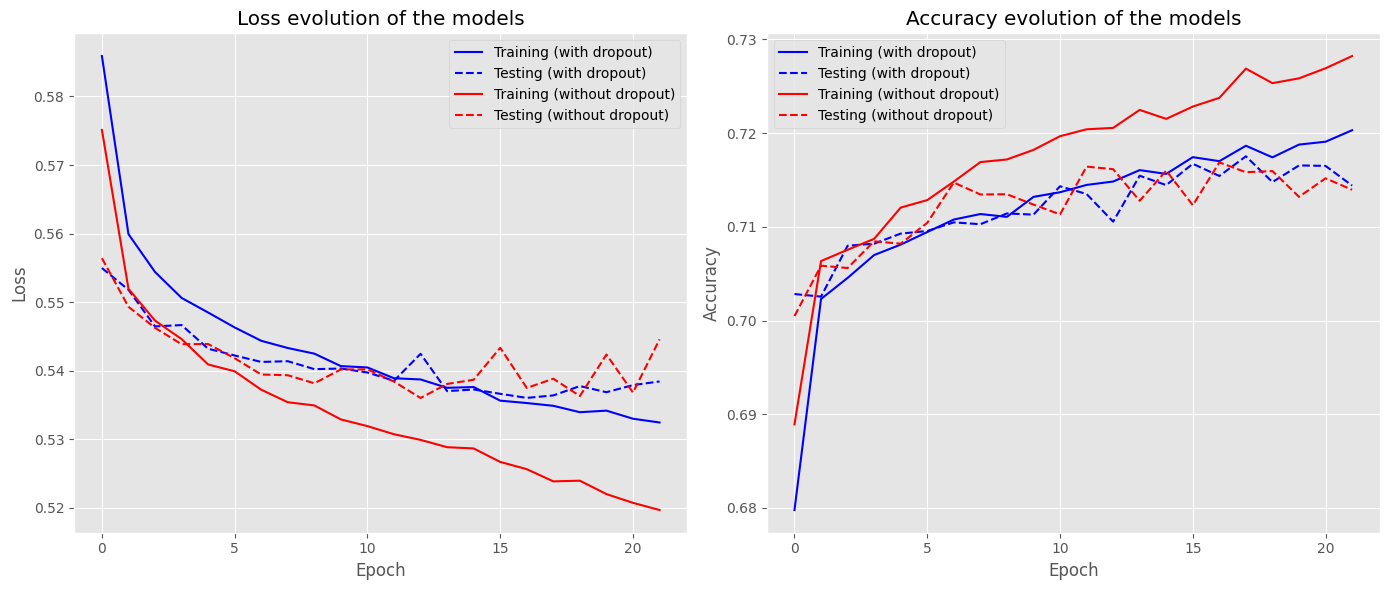

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(121)
plt.plot(train_1.history["loss"], color='blue', label="Training (with dropout)")
plt.plot(train_1.history["val_loss"], color="blue", linestyle="--", label="Testing (with dropout)")
plt.plot(train_2.history["loss"], color='red', label="Training (without dropout)")
plt.plot(train_2.history["val_loss"], color="red", linestyle="--", label="Testing (without dropout)")
# plt.plot([0,500], [var,var], "g--", label="Error variance")
plt.title("Loss evolution of the models")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
# plt.ylim(0,1)

plt.subplot(122)
plt.plot(train_1.history["accuracy"], color='blue', label="Training (with dropout)")
plt.plot(train_1.history["val_accuracy"], color="blue", linestyle="--", label="Testing (with dropout)")
plt.plot(train_2.history["accuracy"], color='red', label="Training (without dropout)")
plt.plot(train_2.history["val_accuracy"], color="red", linestyle="--", label="Testing (without dropout)")
# plt.plot([0,500], [var,var], "g--", label="Error variance")
plt.title("Accuracy evolution of the models")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
# plt.title("With dropout", loc='center', fontsize=13)
# plt.ylim(0,1)
plt.tight_layout()
plt.show()

In [ ]:
train_1.history["val_accuracy"][-1]

0.7143999934196472

In [ ]:
train_1.history["accuracy"][-1]

0.7203062772750854

In [ ]:
print(scores_drop_1, best_drop_1)

[0.71530125 0.71474874 0.715165   0.7143225  0.71450751] {'mode': False, 'rate': None}


In [ ]:
train_3 = train_model(train_X_2, train_labels_2, val_X=test_X_2, val_y=test_labels_2, dim_arr=[21, 512, 256, 128, 64, 1], learning_rate=0.001, batch_size=512, epochs=22, dropout=True, dropout_rate=0.3, standardise='same')

/Users/lizhengyang/miniconda3/envs/ic_math/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_222"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1002 (Dense)              │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1003 (Dense)              │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_116 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1004 (Dense)              │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_117 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1005 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_118 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1006 (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6773 - loss: 0.5869 - val_accuracy: 0.6928 - val_loss: 0.5604
Epoch 2/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6963 - loss: 0.5583 - val_accuracy: 0.6979 - val_loss: 0.5522
Epoch 3/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7044 - loss: 0.5504 - val_accuracy: 0.6999 - val_loss: 0.5493
Epoch 4/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7051 - loss: 0.5491 - val_accuracy: 0.7037 - val_loss: 0.5480
Epoch 5/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7098 - loss: 0.5448 - val_accuracy: 0.7037 - val_loss: 0.5480
Epoch 6/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7102 - loss: 0.5431 - val_accuracy: 0.7055 - val_loss: 0.5452
Epoch 7/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7106 - loss: 0.5431 - val_accuracy: 0.7073 - val_loss: 0.5441
Epoch 8/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7135 - loss: 0.5397 - val_accuracy: 0.

In [ ]:
train_4 = train_model(train_X_2, train_labels_2, val_X=test_X_2, val_y=test_labels_2, dim_arr=[21, 512, 256, 128, 64, 1], learning_rate=0.001, batch_size=512, epochs=22, dropout=False, standardise='same')

/Users/lizhengyang/miniconda3/envs/ic_math/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_223"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1007 (Dense)              │ (None, 512)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1008 (Dense)              │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1009 (Dense)              │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1010 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1011 (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6852 - loss: 0.5756 - val_accuracy: 0.6948 - val_loss: 0.5558
Epoch 2/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7029 - loss: 0.5487 - val_accuracy: 0.7018 - val_loss: 0.5486
Epoch 3/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7082 - loss: 0.5417 - val_accuracy: 0.7065 - val_loss: 0.5443
Epoch 4/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7125 - loss: 0.5380 - val_accuracy: 0.7054 - val_loss: 0.5478
Epoch 5/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7137 - loss: 0.5389 - val_accuracy: 0.7021 - val_loss: 0.5477
Epoch 6/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7147 - loss: 0.5369 - val_accuracy: 0.7088 - val_loss: 0.5417
Epoch 7/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7181 - loss: 0.5332 - val_accuracy: 0.7092 - val_loss: 0.5419
Epoch 8/22
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7183 - loss: 0.5326 - val_accuracy: 0.

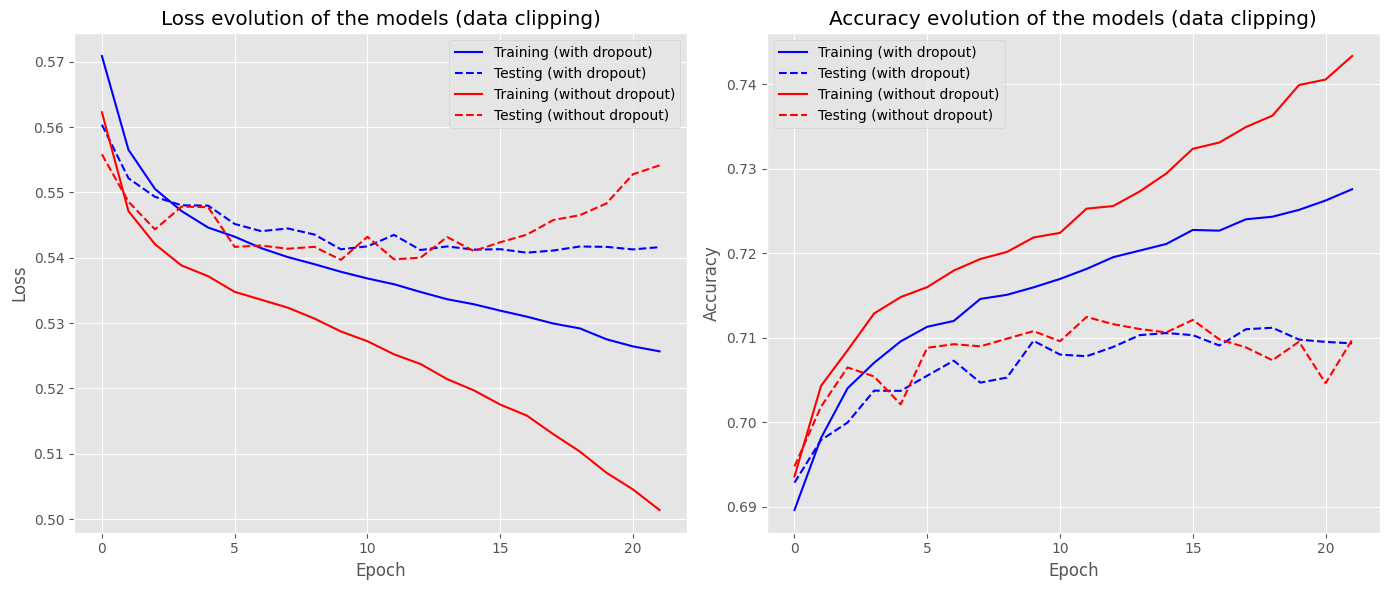

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(121)
plt.plot(train_3.history["loss"], color='blue', label="Training (with dropout)")
plt.plot(train_3.history["val_loss"], color="blue", linestyle="--", label="Testing (with dropout)")
plt.plot(train_4.history["loss"], color='red', label="Training (without dropout)")
plt.plot(train_4.history["val_loss"], color="red", linestyle="--", label="Testing (without dropout)")
# plt.plot([0,500], [var,var], "g--", label="Error variance")
plt.title("Loss evolution of the models (data clipping)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
# plt.ylim(0,1)

plt.subplot(122)
plt.plot(train_3.history["accuracy"], color='blue', label="Training (with dropout)")
plt.plot(train_3.history["val_accuracy"], color="blue", linestyle="--", label="Testing (with dropout)")
plt.plot(train_4.history["accuracy"], color='red', label="Training (without dropout)")
plt.plot(train_4.history["val_accuracy"], color="red", linestyle="--", label="Testing (without dropout)")
# plt.plot([0,500], [var,var], "g--", label="Error variance")
plt.title("Accuracy evolution of the models (data clipping)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
# plt.title("With dropout", loc='center', fontsize=13)
# plt.ylim(0,1)
plt.tight_layout()
plt.show()

## Predict the labels

In [ ]:
# Part B
# read the Data B
data_b = pd.read_csv("DL-2024-CW-data/Data_B_nolabels.csv", header=None)
data_labels_b = data_b[0].to_numpy()
data_labels_b_arr = data_labels_b.reshape(-1, 1)
data_arr_b = data_b.to_numpy()


def model_predict(model, train_data, test_data):
    mu, sigma, X_std = standardise_features(train_data)
    # price and volume
    features_1 = test_data[:, 0:16]
    # previous states
    features_2 = test_data[:, 16:]
    features_1 = (features_1 - mu) / sigma
    test_X_std = np.hstack((features_1, features_2))
    predicted = model.predict(test_X_std)
    predicted_output = (predicted >= 0.5).astype(int)
    np.savetxt("02054603_Li.txt", predicted_output, fmt="%d")

    return predicted_output

In [ ]:
y_predicted = model_predict(train_1.model, train_X_1, data_arr_b)

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step


In [ ]:
print(y_predicted)

[[1]
 [0]
 [1]
 ...
 [0]
 [0]
 [0]]


## Additional Feature Engineering

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import tensorflow.keras as keras

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# organise extended data
data = pd.read_csv("/Users/lizhengyang/Downloads/Data_A.csv", header=None)


X = data.iloc[:, 1:]
y = data.iloc[:, 0] 


X["Book order level 1, sell volume / buy volume"] = np.log(X.iloc[:, 1] / X.iloc[:, 3])
X["Book order level 1, sell price / buy price"] = np.log(X.iloc[:, 0] / X.iloc[:, 2])


scaler = StandardScaler()
X.columns = X.columns.astype(str)


X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [7]:
model = Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)), 
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),  
    keras.layers.Dense(1, activation="sigmoid")
])

/Users/lizhengyang/miniconda3/envs/ic_math/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

In [314]:
history = model.fit(X_train, y_train, 
                    validation_split=0.2, 
                    epochs=20, 
                    batch_size=32, 
                    verbose=1)
model.save("binary_classifier_model.h5") 
print("Model saved as 'binary_classifier_model.h5'.")


Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 2s 390us/step - accuracy: 0.6797 - loss: 0.5900 - val_accuracy: 0.7020 - val_loss: 0.5528
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1s 366us/step - accuracy: 0.6996 - loss: 0.5585 - val_accuracy: 0.7039 - val_loss: 0.5440
Epoch 3/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1s 371us/step - accuracy: 0.7051 - loss: 0.5471 - val_accuracy: 0.7100 - val_loss: 0.5346
Epoch 4/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1s 368us/step - accuracy: 0.7062 - loss: 0.5403 - val_accuracy: 0.7107 - val_loss: 0.5310
Epoch 5/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1s 367us/step - accuracy: 0.7077 - loss: 0.5355 - val_accuracy: 0.7114 - val_loss: 0.5279
Epoch 6/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1s 367us/step - accuracy: 0.7074 - loss: 0.5339 - val_accuracy: 0.7122 - val_loss: 0.5284
Epoch 7/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 2s 392us/step - accuracy: 0.7096 - loss: 0.5320 - val_accuracy: 0.7145 - val_loss: 0.5277
Epoch 8/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 1s 365us/step - accuracy: 0.7111 -

Model saved as 'binary_classifier_model.h5'.


In [315]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 199us/step
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73     19963
           1       0.74      0.68      0.71     20037

    accuracy                           0.72     40000
   macro avg       0.72      0.72      0.72     40000
weighted avg       0.72      0.72      0.72     40000

Confusion Matrix:
[[15226  4737]
 [ 6335 13702]]


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam


model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),  
    Dropout(0.3),  
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

model.compile(
    optimizer=Adam(learning_rate=0.00005), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,361 (185.00 KB)

 Trainable params: 47,361 (185.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 5s 996us/step - accuracy: 0.6167 - loss: 0.6462 - val_accuracy: 0.6869 - val_loss: 0.5763
Epoch 2/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 4s 920us/step - accuracy: 0.6799 - loss: 0.5928 - val_accuracy: 0.6930 - val_loss: 0.5703
Epoch 3/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 4s 946us/step - accuracy: 0.6881 - loss: 0.5830 - val_accuracy: 0.6949 - val_loss: 0.5660
Epoch 4/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 3s 864us/step - accuracy: 0.6870 - loss: 0.5779 - val_accuracy: 0.7003 - val_loss: 0.5617
Epoch 5/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 3s 848us/step - accuracy: 0.6940 - loss: 0.5708 - val_accuracy: 0.7017 - val_loss: 0.5590
Epoch 6/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 4s 923us/step - accuracy: 0.6952 - loss: 0.5692 - val_accuracy: 0.7032 - val_loss: 0.5560
Epoch 7/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 4s 914us/step - accuracy: 0.6984 - loss: 0.5635 - val_accuracy: 0.7048 - val_loss: 0.5538
Epoch 8/200
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 4s 923us/step - accuracy: 

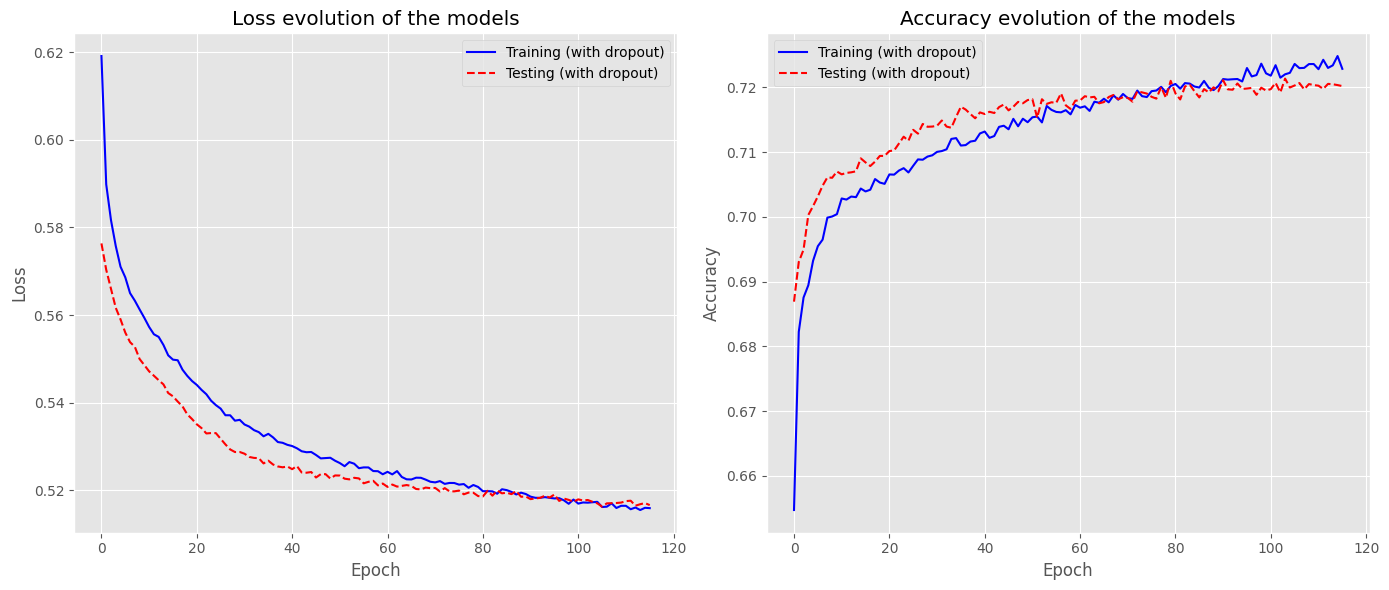

In [13]:
# plot the loss and accuracies
plt.style.use('ggplot')
plt.figure(figsize=(14, 6))

plt.subplot(121)
plt.plot(history.history["loss"], color='blue', label="Training (with dropout)")
plt.plot(history.history["val_loss"], color="red", linestyle="--", label="Testing (with dropout)")
# plt.plot([0,500], [var,var], "g--", label="Error variance")
plt.title("Loss evolution of the models")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
# plt.ylim(0,1)

plt.subplot(122)
plt.plot(history.history["accuracy"], color='blue', label="Training (with dropout)")
plt.plot(history.history["val_accuracy"], color="red", linestyle="--", label="Testing (with dropout)")
# plt.plot([0,500], [var,var], "g--", label="Error variance")
plt.title("Accuracy evolution of the models")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
# plt.title("With dropout", loc='center', fontsize=13)
# plt.ylim(0,1)
plt.tight_layout()
plt.show()

In [15]:
max(history.history["val_accuracy"])

0.7213437557220459